# Домашнее задание: Кластеризация клиентов банка на датсете https://www.kaggle.com/uciml/german-credit
## Часть 1. EDA и Preprocessing

Цель этой части:
   - понять структуру данных о клиентах банка,
   - выявить проблемы качества данных,
   - подготовить корректную числовую матрицу признаков для последующей кластеризации.


### План работы
1. Загрузить данные и проверить базовые свойства (размер, типы, пропуски).
2. Провести EDA: распределения числовых признаков и частоты категорий.
3. Зафиксировать решения по preprocessing.
4. Подготовить матрицу признаков:
   - обработать пропуски,
   - закодировать категориальные признаки,
   - привести признаки к одному масштабу.

Почему это важно для кластеризации: большинство алгоритмов кластеризации опираются на расстояния между объектами. Если признаки в разных единицах измерения (например, `Credit amount` в тысячах и бинарный one-hot признак в 0/1), то признаки с большим масштабом начинают доминировать в расстоянии и искажают результат.


Загружаем необходимые библиотеки и фиксируем единый стиль графиков

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


### 1. Загрузка данных и первичный осмотр

In [2]:
DATA_PATH = 'german_credit_data.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()


Shape: (1000, 10)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.2+ KB


In [4]:
missing = (
    df.isna()
      .sum()
      .to_frame('missing_count')
      .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
      .sort_values('missing_count', ascending=False)
)
missing


,missing_count,missing_pct
Checking account,394,39.4
Saving accounts,183,18.3
Age,0,0.0
Unnamed: 0,0,0.0
Job,0,0.0
Sex,0,0.0
Housing,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


Выводы первичного осмотра:
- В данных `1000` наблюдений и `10` столбцов.
- Колонка `Unnamed: 0` выглядит как технический индекс из исходного CSV, не несет бизнес-смысла как признак.
- Есть пропуски в `Saving accounts` и `Checking account`.
- Признаки смешанные: числовые и категориальные.


### 2. Базовая очистка перед EDA

In [5]:
# Удаляем технический индексный столбец
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print('Columns after cleanup:', list(df.columns))


Columns after cleanup: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


Обоснование: `Unnamed: 0` не описывает клиента и может искусственно влиять на расстояния в кластеризации, если оставить его как числовой признак.


### 3. EDA: числовые признаки

In [6]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

df[num_cols].describe().T


Numeric columns: ['Age', 'Job', 'Credit amount', 'Duration']
Categorical columns: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.0,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


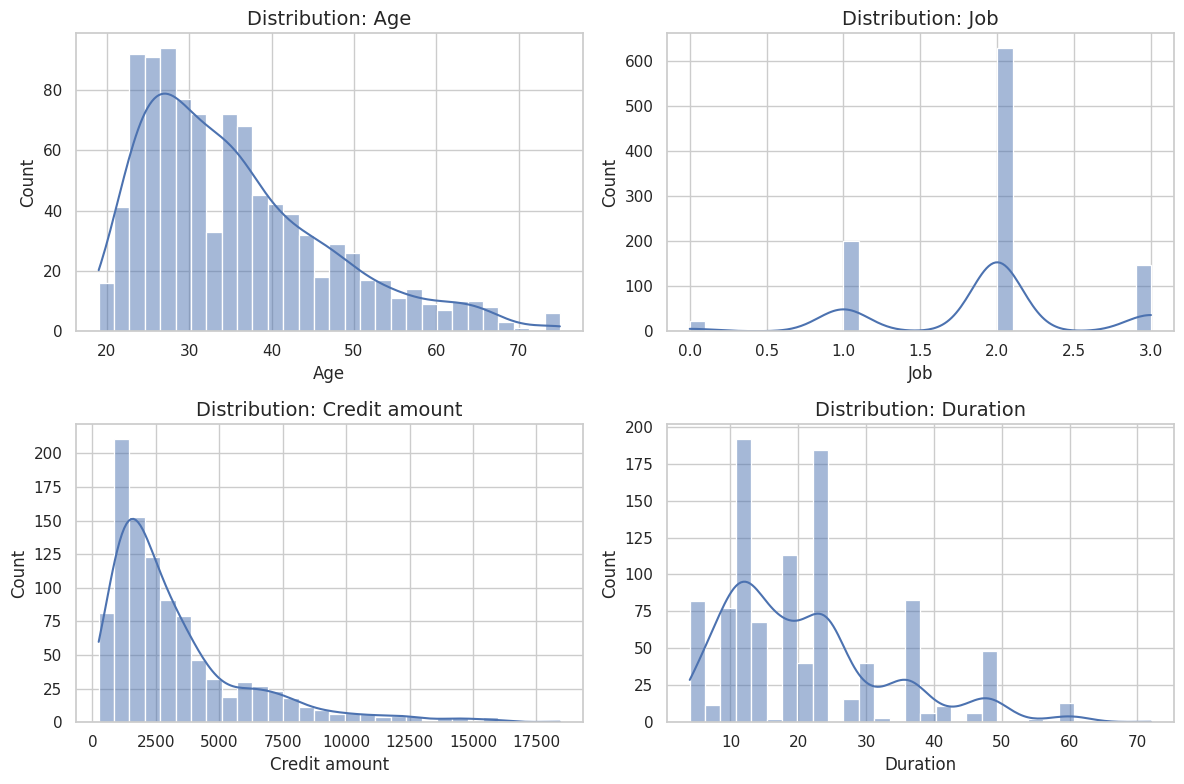

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()


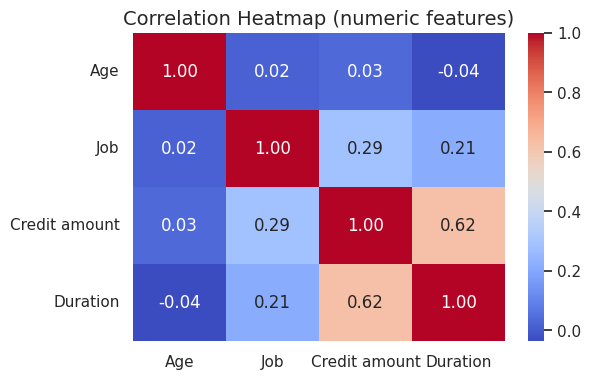

In [8]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (numeric features)')
plt.show()


Наблюдения по числовым признакам:
- `Credit amount` обычно имеет правостороннюю асимметрию (есть клиенты с заметно более крупными суммами кредита).
- `Duration` также несимметричен и содержит более длинные хвосты.
- `Age` распределен более равномерно, но с выбросами в старших возрастах.
- Уже на этом этапе видно, что масштабы признаков различаются существенно, значит нормализация обязательна.


### 4. EDA: категориальные признаки

In [9]:
for col in cat_cols:
    print(f'\n{col}')
    display(df[col].value_counts(dropna=False))



Sex


Sex
male      690
female    310
Name: count, dtype: int64


Housing


Housing
own     713
rent    179
free    108
Name: count, dtype: int64


Saving accounts


Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64


Checking account


Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64


Purpose


Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

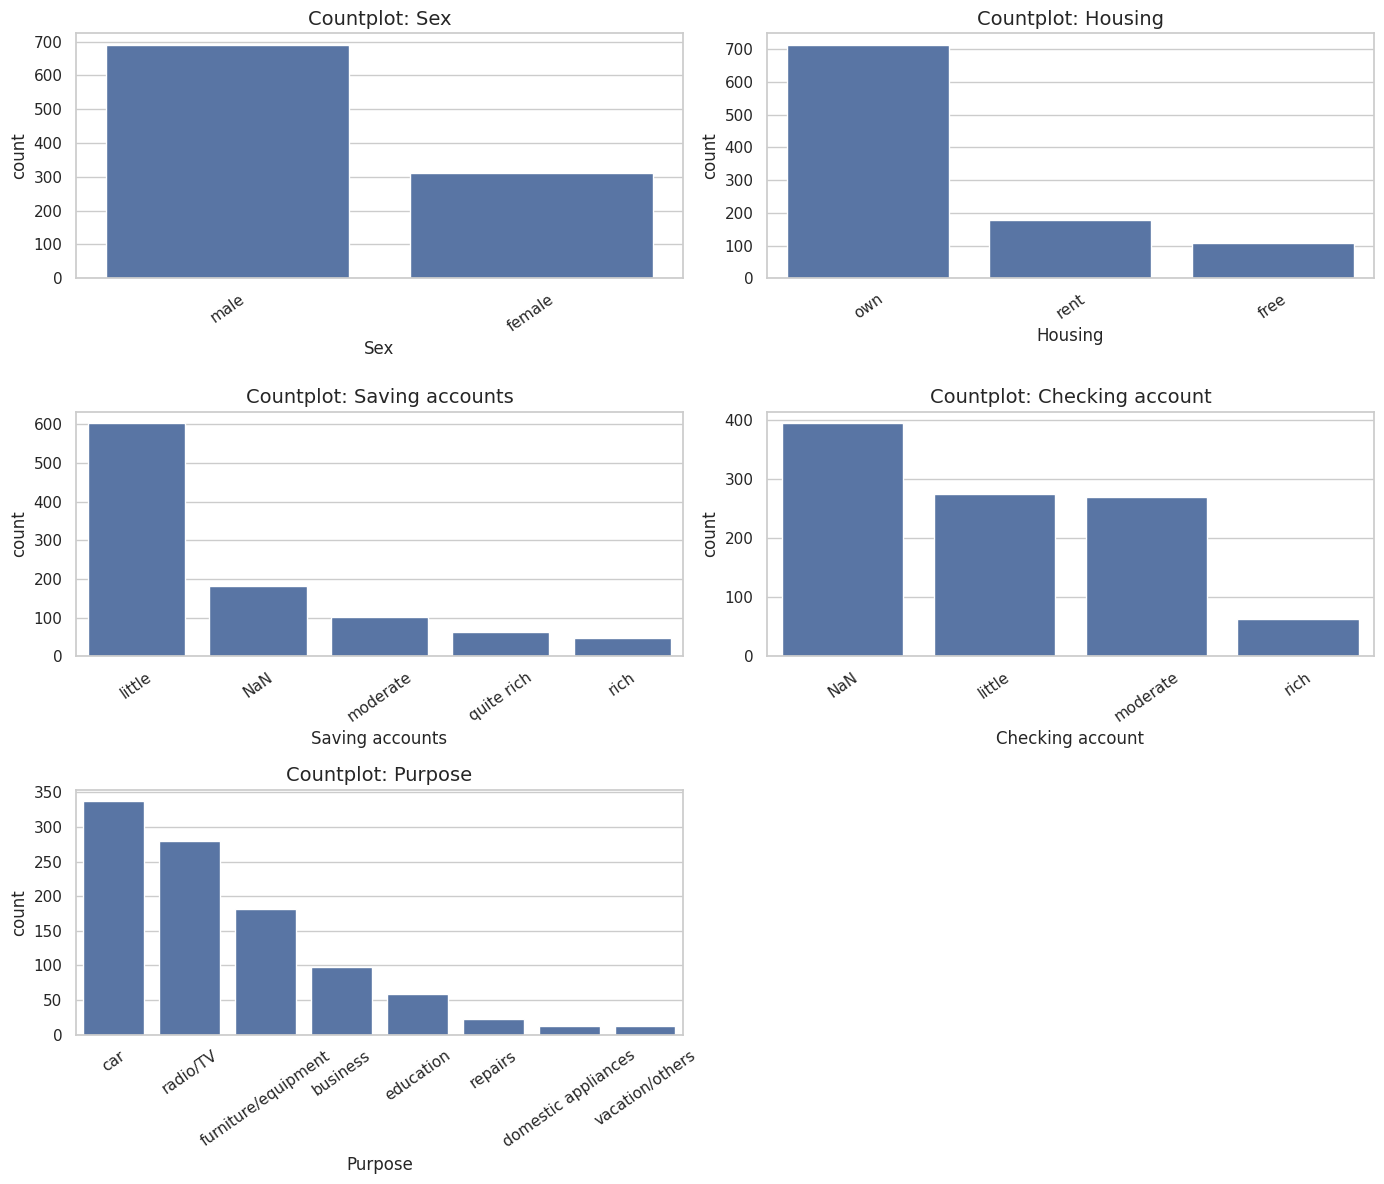

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].fillna('NaN').value_counts().index
    sns.countplot(data=df, x=df[col].fillna('NaN'), order=order, ax=axes[i])
    axes[i].set_title(f'Countplot: {col}')
    axes[i].tick_params(axis='x', rotation=35)

# если осей больше, чем признаков
for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


Наблюдения по категориальным признакам:
- В `Saving accounts` и `Checking account` доля пропусков заметная, ее нельзя игнорировать.
- `Purpose` и финансовые категории многоклассовые, для алгоритмов потребуется кодирование.
- `Sex` и `Housing` номинальные (нет естественного порядка), значит безопаснее использовать one-hot кодирование.


### 5. Preprocessing для кластеризации

Решения по preprocessing:
1. Пропуски в `Saving accounts` и `Checking account` заполнить отдельной категорией `no_info`.
   Это сохраняет информацию о факте отсутствия значения и не вносит произвольных числовых предположений.
2. Категориальные признаки закодировать через one-hot (`drop_first=False`).
   Для кластеризации важно не терять категории; мультиколлинеарность здесь не критична, так как нет задачи интерпретации коэффициентов линейной модели.
3. Все признаки масштабировать с помощью `StandardScaler`.
   После этого у признаков сопоставимый вклад в метрику расстояния.


In [12]:
df_prep = df.copy()

# 1) Заполняем пропуски отдельной категорией
for col in ['Saving accounts', 'Checking account']:
    df_prep[col] = df_prep[col].fillna('no_info')

# 2) Кодируем категориальные признаки
cat_cols_prep = df_prep.select_dtypes(exclude='number').columns.tolist()
df_encoded = pd.get_dummies(
    df_prep,
    columns=cat_cols_prep,
    drop_first=False,
    dtype=int
)

print('Форма таблицы:', df_encoded.shape)
print('Количество нечесловых признаков:', df_encoded.select_dtypes(exclude='number').columns.tolist())
df_encoded.head()


Форма таблицы: (1000, 26)
Количество нечесловых признаков: []


,Age,Job,Credit amount,Duration,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,Saving accounts_no_info,Saving accounts_quite rich,Saving accounts_rich,Checking account_little,Checking account_moderate,Checking account_no_info,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1,22,2,5951,48,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,49,1,2096,12,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
3,45,2,7882,42,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
4,53,2,4870,24,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0


In [13]:
# 3) Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

X_scaled_df = pd.DataFrame(X_scaled, columns=df_encoded.columns)

print('Форма отмасштабированной матрицы:', X_scaled_df.shape)
X_scaled_df.describe().T[['mean', 'std']].head(10)


Форма отмасштабированной матрицы: (1000, 26)


,mean,std
Age,5.329071e-17,1.0005
Job,5.684342e-17,1.0005
Credit amount,6.661338e-17,1.0005
Duration,1.136868e-16,1.0005
Sex_female,-6.572520e-17,1.0005
Sex_male,6.572520e-17,1.0005
Housing_free,3.907985e-17,1.0005
Housing_own,5.329071e-17,1.0005
Housing_rent,-6.394885e-17,1.0005
Saving accounts_little,-1.776357e-18,1.0005


In [14]:
# Проверим диапазон средних и std после масштабирования
mean_abs_max = X_scaled_df.mean().abs().max()
std_min = X_scaled_df.std(ddof=0).min()
std_max = X_scaled_df.std(ddof=0).max()

print(f'Максимальное среднее значение после масштабирования: {mean_abs_max:.6f}')
print(f'Стандартное отклонение после масштабирования: [{std_min:.6f}, {std_max:.6f}]')


Максимальное среднее значение после масштабирования: 0.000000
Стандартное отклонение после масштабирования: [1.000000, 1.000000]


### 5.1 Boxplot масштабированных признаков

Ниже показаны boxplot для **исходно числовых признаков после масштабирования** (`Age`, `Job`, `Credit amount`, `Duration`).

Мы масштабировали все признаки, включая one-hot признаки, но для бинарных one-hot boxplot обычно менее информативен. Поэтому для визуальной проверки эффекта `StandardScaler` логично смотреть на исходные количественные признаки.


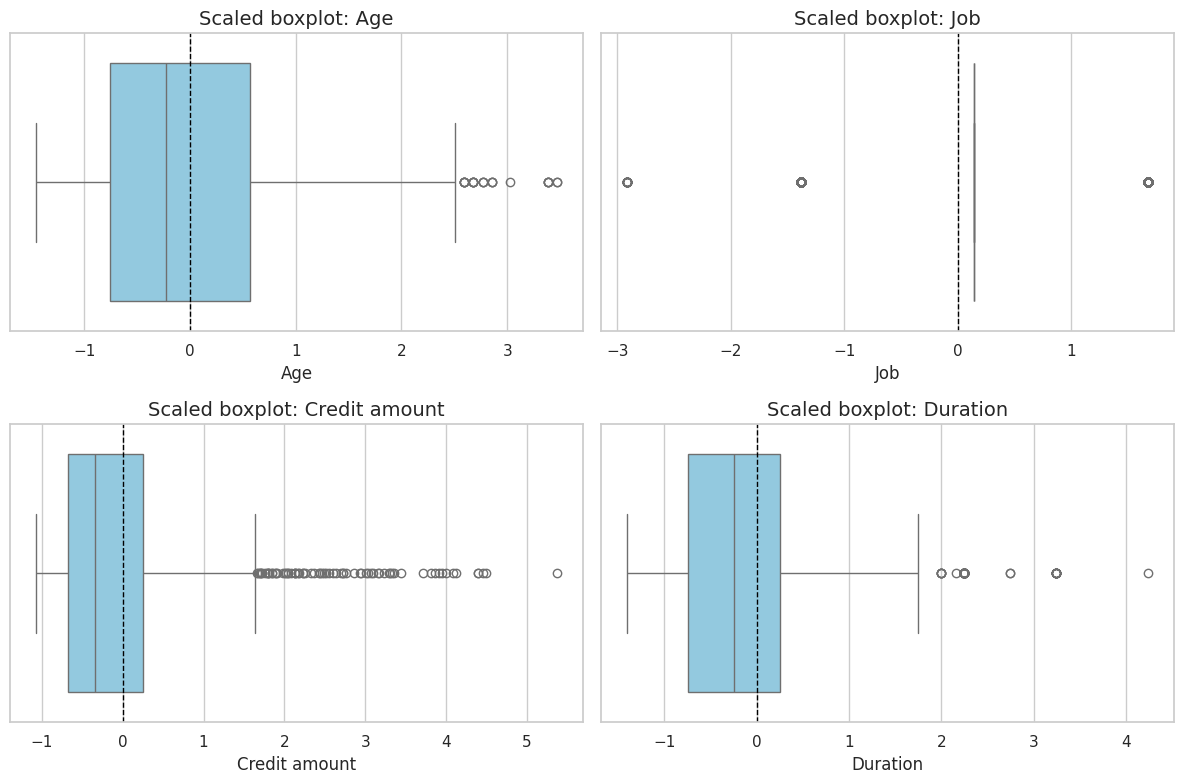

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=X_scaled_df[col], ax=ax, color='skyblue')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Scaled boxplot: {col}')

plt.tight_layout()
plt.show()


### Результат Часть 1
- Проведен EDA: изучены типы признаков, пропуски, распределения числовых и категориальных переменных.
- Удален технический столбец `Unnamed: 0`.
- Пропуски в финансовых категориальных признаках обработаны как отдельная категория `no_info`.
- Все категориальные признаки закодированы в числовой формат (one-hot).
- Все признаки приведены к единому масштабу (`StandardScaler`).

Итог: сформирована полностью числовая и масштабированная матрица признаков `X_scaled_df`, готовая для этапа кластеризации.


## Часть 2. Моделирование

В этой части строим три подхода к кластеризации:
- `KMeans`
- `Hierarchical (Agglomerative, Ward linkage)`
- `DBSCAN`

Для выбора параметров используем:
- `Elbow method`
- `Silhouette score/plot`

После этого визуализируем результаты в 2D через `PCA`, `UMAP` и `t-SNE`.


In [16]:
import os

# UMAP использует numba; в локальной файловой системе нужно направить кэш в /tmp
os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba_cache')
os.environ.setdefault('NUMBA_DISABLE_CACHING', '1')
os.makedirs('/tmp/numba_cache', exist_ok=True)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap


In [20]:
X = X_scaled_df.values
print('X shape:', X.shape)
print('Feature count:', X.shape[1])


X shape: (1000, 26)
Feature count: 26


### 2.1 KMeans и Hierarchical: подбор количества кластеров

Подход:
1. Строим кривые Elbow (`inertia`/`WCSS`) для диапазона `k`.
2. Строим кривые `silhouette` для того же диапазона.
3. Определяем `k_elbow` как точку излома.
4. Финальный `k` выбираем как максимум silhouette в окне `[k_elbow, k_elbow + 3]`.

Такой выбор дает компромисс: не слишком рано остановиться в elbow и при этом не брать избыточно большое количество кластеров только ради максимума silhouette.


In [21]:
def compute_wcss(X, labels):
    """Within-cluster sum of squares для произвольной кластеризации."""
    total = 0.0
    for cluster_id in np.unique(labels):
        cluster_points = X[labels == cluster_id]
        center = cluster_points.mean(axis=0)
        total += ((cluster_points - center) ** 2).sum()
    return total


def find_elbow_k(k_values, metric_values):
    """Находит 'локоть' как максимальное отклонение от линии между краями кривой."""
    k_arr = np.array(list(k_values), dtype=float)
    y_arr = np.array(metric_values, dtype=float)

    x_norm = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    y_norm = (y_arr - y_arr.min()) / (y_arr.max() - y_arr.min())

    line = y_norm[0] + (y_norm[-1] - y_norm[0]) * (x_norm - x_norm[0]) / (x_norm[-1] - x_norm[0])
    distances = line - y_norm

    return int(k_arr[np.argmax(distances)])


def choose_k_by_elbow_and_silhouette(metrics_df, elbow_k, window=3):
    candidates = metrics_df[(metrics_df['k'] >= elbow_k) & (metrics_df['k'] <= elbow_k + window)]
    best_idx = candidates['silhouette'].idxmax()
    return int(metrics_df.loc[best_idx, 'k'])


k_range = list(range(2, 11))

kmeans_rows = []
agg_rows = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans_labels = kmeans.fit_predict(X)

    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agg.fit_predict(X)

    kmeans_rows.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(X, kmeans_labels)
    })

    agg_rows.append({
        'k': k,
        'wcss': compute_wcss(X, agg_labels),
        'silhouette': silhouette_score(X, agg_labels)
    })

kmeans_metrics = pd.DataFrame(kmeans_rows)
agg_metrics = pd.DataFrame(agg_rows)

kmeans_elbow_k = find_elbow_k(kmeans_metrics['k'], kmeans_metrics['inertia'])
agg_elbow_k = find_elbow_k(agg_metrics['k'], agg_metrics['wcss'])

chosen_kmeans_k = choose_k_by_elbow_and_silhouette(kmeans_metrics, kmeans_elbow_k, window=3)
chosen_agg_k = choose_k_by_elbow_and_silhouette(agg_metrics, agg_elbow_k, window=3)

print(f'KMeans elbow k: {kmeans_elbow_k}, chosen k: {chosen_kmeans_k}')
print(f'Agglomerative elbow k: {agg_elbow_k}, chosen k: {chosen_agg_k}')

print('\nKMeans metrics:')
print(kmeans_metrics.round(4).to_string(index=False))

print('\nAgglomerative metrics:')
print(agg_metrics.round(4).to_string(index=False))


KMeans elbow k: 4, chosen k: 6
Agglomerative elbow k: 5, chosen k: 8

KMeans metrics:
 k    inertia  silhouette
 2 23847.9659      0.1059
 3 22444.5051      0.1126
 4 21221.9396      0.1149
 5 20349.2752      0.0905
 6 19420.9244      0.1335
 7 18740.2949      0.1141
 8 17835.5739      0.1276
 9 16951.9405      0.1402
10 16029.8699      0.1305

Agglomerative metrics:
 k       wcss  silhouette
 2 24705.6141      0.0933
 3 23510.5073      0.0888
 4 22422.3887      0.0874
 5 21351.4958      0.1064
 6 20311.2870      0.1218
 7 19293.3715      0.1358
 8 18288.8720      0.1491
 9 17286.7259      0.1486
10 16356.5194      0.1631


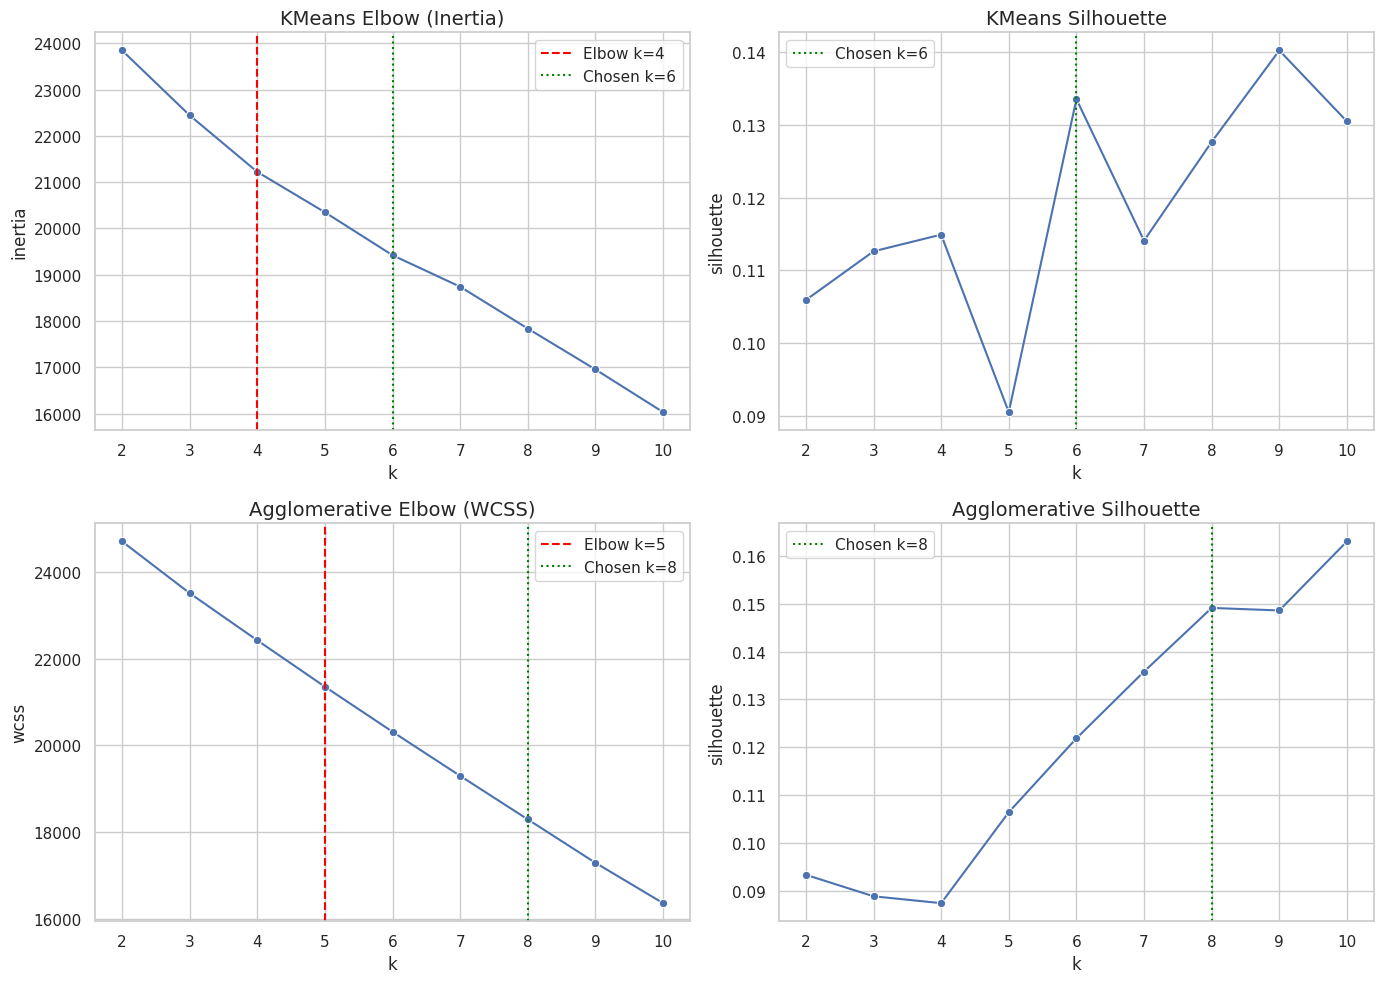

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KMeans Elbow
sns.lineplot(data=kmeans_metrics, x='k', y='inertia', marker='o', ax=axes[0, 0])
axes[0, 0].axvline(kmeans_elbow_k, color='red', linestyle='--', label=f'Elbow k={kmeans_elbow_k}')
axes[0, 0].axvline(chosen_kmeans_k, color='green', linestyle=':', label=f'Chosen k={chosen_kmeans_k}')
axes[0, 0].set_title('KMeans Elbow (Inertia)')
axes[0, 0].legend()

# KMeans Silhouette
sns.lineplot(data=kmeans_metrics, x='k', y='silhouette', marker='o', ax=axes[0, 1])
axes[0, 1].axvline(chosen_kmeans_k, color='green', linestyle=':', label=f'Chosen k={chosen_kmeans_k}')
axes[0, 1].set_title('KMeans Silhouette')
axes[0, 1].legend()

# Agglomerative Elbow
sns.lineplot(data=agg_metrics, x='k', y='wcss', marker='o', ax=axes[1, 0])
axes[1, 0].axvline(agg_elbow_k, color='red', linestyle='--', label=f'Elbow k={agg_elbow_k}')
axes[1, 0].axvline(chosen_agg_k, color='green', linestyle=':', label=f'Chosen k={chosen_agg_k}')
axes[1, 0].set_title('Agglomerative Elbow (WCSS)')
axes[1, 0].legend()

# Agglomerative Silhouette
sns.lineplot(data=agg_metrics, x='k', y='silhouette', marker='o', ax=axes[1, 1])
axes[1, 1].axvline(chosen_agg_k, color='green', linestyle=':', label=f'Chosen k={chosen_agg_k}')
axes[1, 1].set_title('Agglomerative Silhouette')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


Итог по выбору `k` (конкретные значения выводятся в предыдущей code-ячейке):
- `KMeans`: `k` выбираем как максимум силуэтного коэффициента (silhouette) после точки по методу локтя (elbow).
- `Agglomerative`: тот же критерий выбора `k`.

Это дает управляемый баланс между компактностью кластеров (elbow) и их разделимостью (silhouette).


### 2.1.1 Размеры кластеров по k (KMeans)

Чтобы выбор `k` был прозрачным, посмотрим не только на метрики, но и на размеры кластеров.
Если при увеличении `k` появляются очень маленькие группы, это часто признак пере-дробления сегментов.


,k,min_cluster_size,max_cluster_size,cluster_sizes_sorted
0,2,310,690,"[690, 310]"
1,3,116,594,"[594, 290, 116]"
2,4,108,517,"[517, 196, 179, 108]"
3,5,108,295,"[295, 222, 196, 179, 108]"
4,6,48,426,"[426, 202, 156, 106, 62, 48]"
5,7,12,364,"[364, 233, 135, 132, 102, 22, 12]"
6,8,22,326,"[326, 137, 132, 131, 98, 91, 63, 22]"
7,9,12,313,"[313, 143, 126, 114, 96, 77, 62, 57, 12]"
8,10,12,243,"[243, 201, 187, 97, 91, 89, 46, 22, 12, 12]"


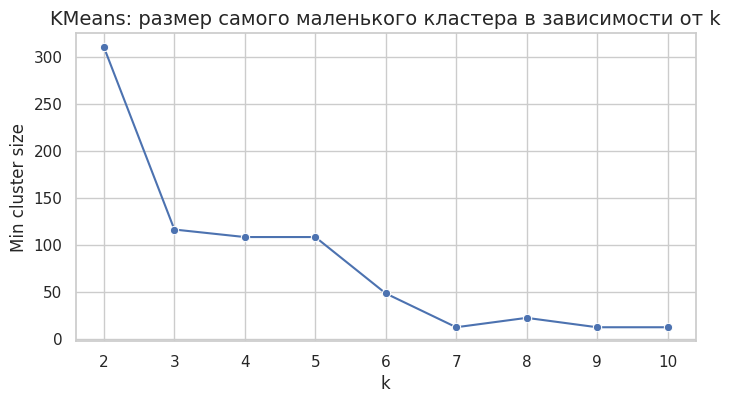

Сравнение k=6 и k=9:
k=6 sizes: [426, 202, 156, 106, 62, 48]
k=9 sizes: [313, 143, 126, 114, 96, 77, 62, 57, 12]


In [23]:
kmeans_size_rows = []

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X)
    _, counts = np.unique(labels, return_counts=True)
    counts_sorted = sorted(counts.tolist(), reverse=True)

    kmeans_size_rows.append({
        'k': k,
        'min_cluster_size': min(counts_sorted),
        'max_cluster_size': max(counts_sorted),
        'cluster_sizes_sorted': counts_sorted
    })

kmeans_cluster_sizes_df = pd.DataFrame(kmeans_size_rows)

display(kmeans_cluster_sizes_df)

plt.figure(figsize=(8, 4))
sns.lineplot(data=kmeans_cluster_sizes_df, x='k', y='min_cluster_size', marker='o')
plt.title('KMeans: размер самого маленького кластера в зависимости от k')
plt.xlabel('k')
plt.ylabel('Min cluster size')
plt.show()

print('Сравнение k=6 и k=9:')
print('k=6 sizes:', kmeans_cluster_sizes_df.loc[kmeans_cluster_sizes_df['k'] == 6, 'cluster_sizes_sorted'].iloc[0])
print('k=9 sizes:', kmeans_cluster_sizes_df.loc[kmeans_cluster_sizes_df['k'] == 9, 'cluster_sizes_sorted'].iloc[0])


### 2.2 DBSCAN: подбор `eps` и `min_samples`

Для DBSCAN количество кластеров не задается напрямую. Поэтому:
1. Используем `k-distance plot` как аналог Elbow для подбора `eps`.
2. Делаем сеточный перебор `eps` и `min_samples`.
3. Оцениваем:
   - `silhouette` (по ненулевым кластерам, без шума),
   - долю шума,
   - долю самого большого кластера (чтобы избегать почти тривиальных решений, где почти все точки в одном кластере).


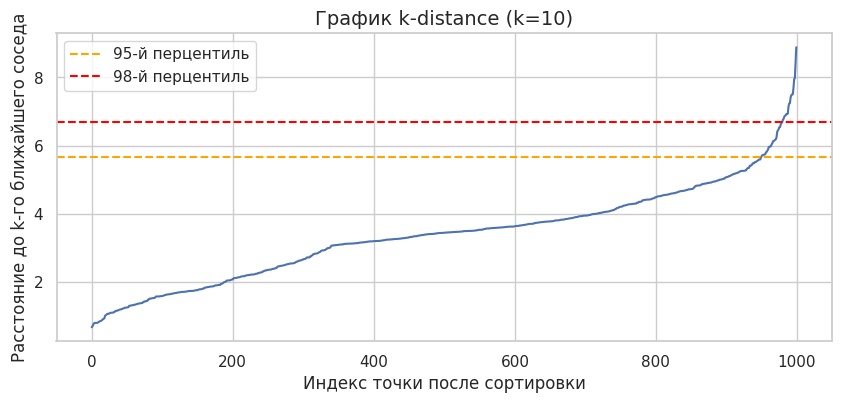

Перцентили k-distance:
P90: 5.066
P95: 5.653
P98: 6.684


In [26]:
# 1) График k-distance (аналог Elbow для DBSCAN)
min_samples_for_kdist = 10
nn = NearestNeighbors(n_neighbors=min_samples_for_kdist)
nn.fit(X)
distances, _ = nn.kneighbors(X)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances)
plt.axhline(np.percentile(k_distances, 95), color='orange', linestyle='--', label='95-й перцентиль')
plt.axhline(np.percentile(k_distances, 98), color='red', linestyle='--', label='98-й перцентиль')
plt.title(f'График k-distance (k={min_samples_for_kdist})')
plt.xlabel('Индекс точки после сортировки')
plt.ylabel('Расстояние до k-го ближайшего соседа')
plt.legend()
plt.show()

print('Перцентили k-distance:')
for q in [90, 95, 98]:
    print(f'P{q}: {np.percentile(k_distances, q):.3f}')


In [27]:
# 2) Сеточный подбор DBSCAN

eps_grid = np.round(np.arange(3.2, 6.2, 0.2), 2)
min_samples_grid = [5, 8, 10, 12]

dbscan_rows = []

for min_samples in min_samples_grid:
    for eps in eps_grid:
        model = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels = model.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = float((labels == -1).mean())

        silhouette_non_noise = np.nan
        largest_cluster_ratio = np.nan

        non_noise_labels = labels[labels != -1]
        if non_noise_labels.size > 0:
            _, counts = np.unique(non_noise_labels, return_counts=True)
            largest_cluster_ratio = counts.max() / non_noise_labels.size

        if n_clusters >= 2 and non_noise_labels.size > 1:
            mask = labels != -1
            silhouette_non_noise = silhouette_score(X[mask], labels[mask])

        dbscan_rows.append({
            'eps': float(eps),
            'min_samples': int(min_samples),
            'n_clusters': int(n_clusters),
            'noise_ratio': noise_ratio,
            'silhouette_non_noise': silhouette_non_noise,
            'largest_cluster_ratio': largest_cluster_ratio
        })


dbscan_search = pd.DataFrame(dbscan_rows)

# Кандидаты: не слишком много шума, не слишком тривиально, и разумное число кластеров
candidate_mask = (
    dbscan_search['n_clusters'].between(3, 8)
    & (dbscan_search['noise_ratio'] <= 0.10)
    & (dbscan_search['largest_cluster_ratio'] <= 0.85)
)

dbscan_candidates = dbscan_search[candidate_mask].sort_values(
    ['silhouette_non_noise', 'noise_ratio'], ascending=[False, True]
)

print('Лучшие конфигурации для DBSCAN (filtered):')
print(dbscan_candidates.head(10).round(4).to_string(index=False))

if dbscan_candidates.empty:
    # fallback: просто лучший по silhouette среди решений с >=2 кластерами
    fallback = dbscan_search[dbscan_search['n_clusters'] >= 2].sort_values('silhouette_non_noise', ascending=False).iloc[0]
    chosen_dbscan_eps = float(fallback['eps'])
    chosen_dbscan_min_samples = int(fallback['min_samples'])
else:
    chosen_dbscan_eps = float(dbscan_candidates.iloc[0]['eps'])
    chosen_dbscan_min_samples = int(dbscan_candidates.iloc[0]['min_samples'])

print(f'\nChosen DBSCAN params: eps={chosen_dbscan_eps}, min_samples={chosen_dbscan_min_samples}')


Top DBSCAN configs (filtered):
 eps  min_samples  n_clusters  noise_ratio  silhouette_non_noise  largest_cluster_ratio
 4.4            5           7        0.059                0.1820                 0.7821
 4.6            5           7        0.045                0.1803                 0.8251
 4.4            8           6        0.082                0.1787                 0.7996
 4.4           10           6        0.092                0.1753                 0.8062
 4.6            8           5        0.062                0.1718                 0.8401
 4.6           10           5        0.070                0.1681                 0.8441
 4.2            5           8        0.077                0.1622                 0.7920

Chosen DBSCAN params: eps=4.4, min_samples=5


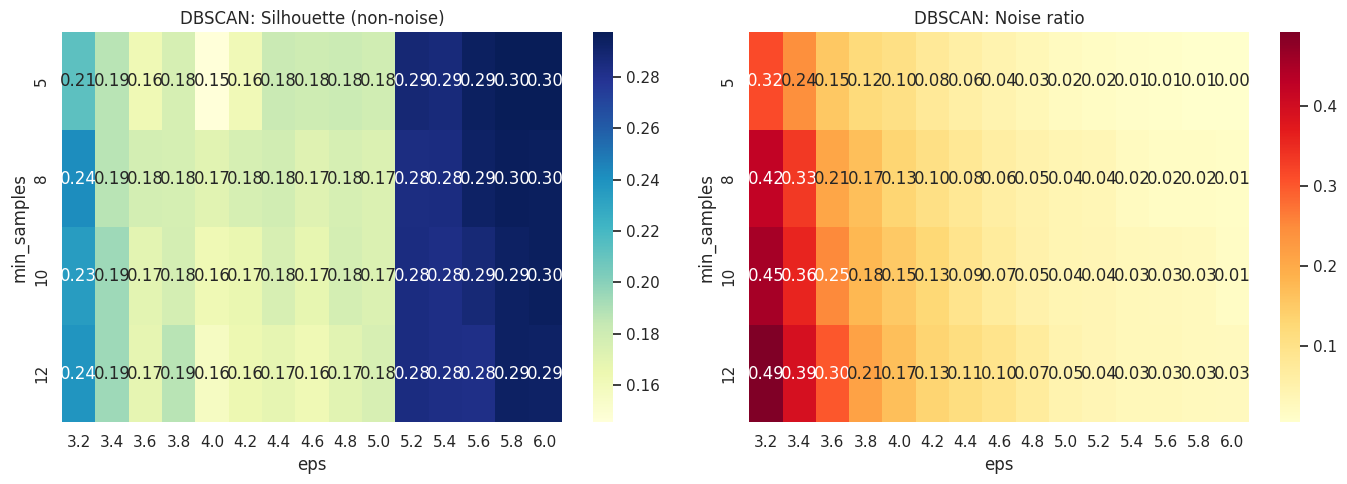

In [22]:
# Визуальные карты качества DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sil_pivot = dbscan_search.pivot(index='min_samples', columns='eps', values='silhouette_non_noise')
noise_pivot = dbscan_search.pivot(index='min_samples', columns='eps', values='noise_ratio')

sns.heatmap(sil_pivot, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('DBSCAN: Silhouette (non-noise)')

sns.heatmap(noise_pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('DBSCAN: Noise ratio')

plt.tight_layout()
plt.show()


### 2.3 Обучение финальных моделей

Используем выбранные параметры и сохраняем метки кластеров для дальнейшей интерпретации (Часть 3).


In [32]:
# Финальные модели
final_kmeans = KMeans(n_clusters=chosen_kmeans_k, random_state=42, n_init=20)
final_agg = AgglomerativeClustering(n_clusters=chosen_agg_k, linkage='ward')
final_dbscan = DBSCAN(eps=chosen_dbscan_eps, min_samples=chosen_dbscan_min_samples)

kmeans_labels = final_kmeans.fit_predict(X)
agg_labels = final_agg.fit_predict(X)
dbscan_labels = final_dbscan.fit_predict(X)

# Метрики
kmeans_sil = silhouette_score(X, kmeans_labels)
agg_sil = silhouette_score(X, agg_labels)

dbscan_n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
dbscan_noise_ratio = float((dbscan_labels == -1).mean())

if dbscan_n_clusters >= 2 and (dbscan_labels != -1).sum() > 1:
    dbscan_sil = silhouette_score(X[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
else:
    dbscan_sil = np.nan

metrics_summary = pd.DataFrame([
    {
        'model': 'KMeans',
        'params': f'k={chosen_kmeans_k}',
        'n_clusters': len(np.unique(kmeans_labels)),
        'noise_ratio': 0.0,
        'silhouette': kmeans_sil
    },
    {
        'model': 'Hierarchical',
        'params': f'k={chosen_agg_k}, linkage=ward',
        'n_clusters': len(np.unique(agg_labels)),
        'noise_ratio': 0.0,
        'silhouette': agg_sil
    },
    {
        'model': 'DBSCAN',
        'params': f'eps={chosen_dbscan_eps}, min_samples={chosen_dbscan_min_samples}',
        'n_clusters': dbscan_n_clusters,
        'noise_ratio': dbscan_noise_ratio,
        'silhouette': dbscan_sil
    }
])

print(metrics_summary.round(4).to_string(index=False))

# Сохраняем датафрейм для Часть 3
# Берем признаки до one-hot (df_prep) + метки кластеров

df_for_interpretation = df_prep.copy()
df_for_interpretation['cluster_kmeans'] = kmeans_labels
df_for_interpretation['cluster_hierarchical'] = agg_labels
df_for_interpretation['cluster_dbscan'] = dbscan_labels

def print_cluster_sizes(labels, model_name, noise_label=None):
    s = pd.Series(labels, name='cluster')
    total = int(s.size)
    table = s.value_counts().sort_index().rename('count').to_frame()
    table['share_%'] = (table['count'] / total * 100).round(1)
    table.index.name = 'cluster_id'
    table = table.reset_index()

    if noise_label is None:
        table['cluster'] = table['cluster_id'].apply(lambda x: f'cluster_{int(x)}')
    else:
        table['cluster'] = table['cluster_id'].apply(lambda x: 'noise' if x == noise_label else f'cluster_{int(x)}')

    table['count'] = table['count'].astype(int)

    print(f'\n{model_name} (n={total})')
    print(table[['cluster', 'count', 'share_%']].to_string(index=False))

print_cluster_sizes(kmeans_labels, 'KMeans')
print_cluster_sizes(agg_labels, 'Hierarchical')
print_cluster_sizes(dbscan_labels, 'DBSCAN', noise_label=-1)


       model                 params  n_clusters  noise_ratio  silhouette
      KMeans                    k=6           6        0.000      0.1335
Hierarchical      k=8, linkage=ward           8        0.000      0.1491
      DBSCAN eps=4.4, min_samples=5           7        0.059      0.1820

KMeans (n=1000)
  cluster  count  share_%
cluster_0     48      4.8
cluster_1    202     20.2
cluster_2    156     15.6
cluster_3    106     10.6
cluster_4    426     42.6
cluster_5     62      6.2

Hierarchical (n=1000)
  cluster  count  share_%
cluster_0    228     22.8
cluster_1     87      8.7
cluster_2    534     53.4
cluster_3     12      1.2
cluster_4     59      5.9
cluster_5     22      2.2
cluster_6     46      4.6
cluster_7     12      1.2

DBSCAN (n=1000)
  cluster  count  share_%
    noise     59      5.9
cluster_0    736     73.6
cluster_1     46      4.6
cluster_2     50      5.0
cluster_3     38      3.8
cluster_4     48      4.8
cluster_5     17      1.7
cluster_6      6      0.6


### 2.4 Понижение размерности и визуализация кластеров

Строим 2D-представления данных с помощью:
- `PCA`
- `UMAP`
- `t-SNE`

И отображаем на них разметку каждого алгоритма кластеризации.


In [33]:
# 2D embeddings
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X)

umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
X_umap = umap_2d.fit_transform(X)

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    max_iter=1000,
    random_state=42
)
X_tsne = tsne_2d.fit_transform(X)

embeddings = {
    'PCA': X_pca,
    'UMAP': X_umap,
    't-SNE': X_tsne
}

print(f'PCA explained variance (2 components): {pca_2d.explained_variance_ratio_.sum():.3f}')


PCA explained variance (2 components): 0.186


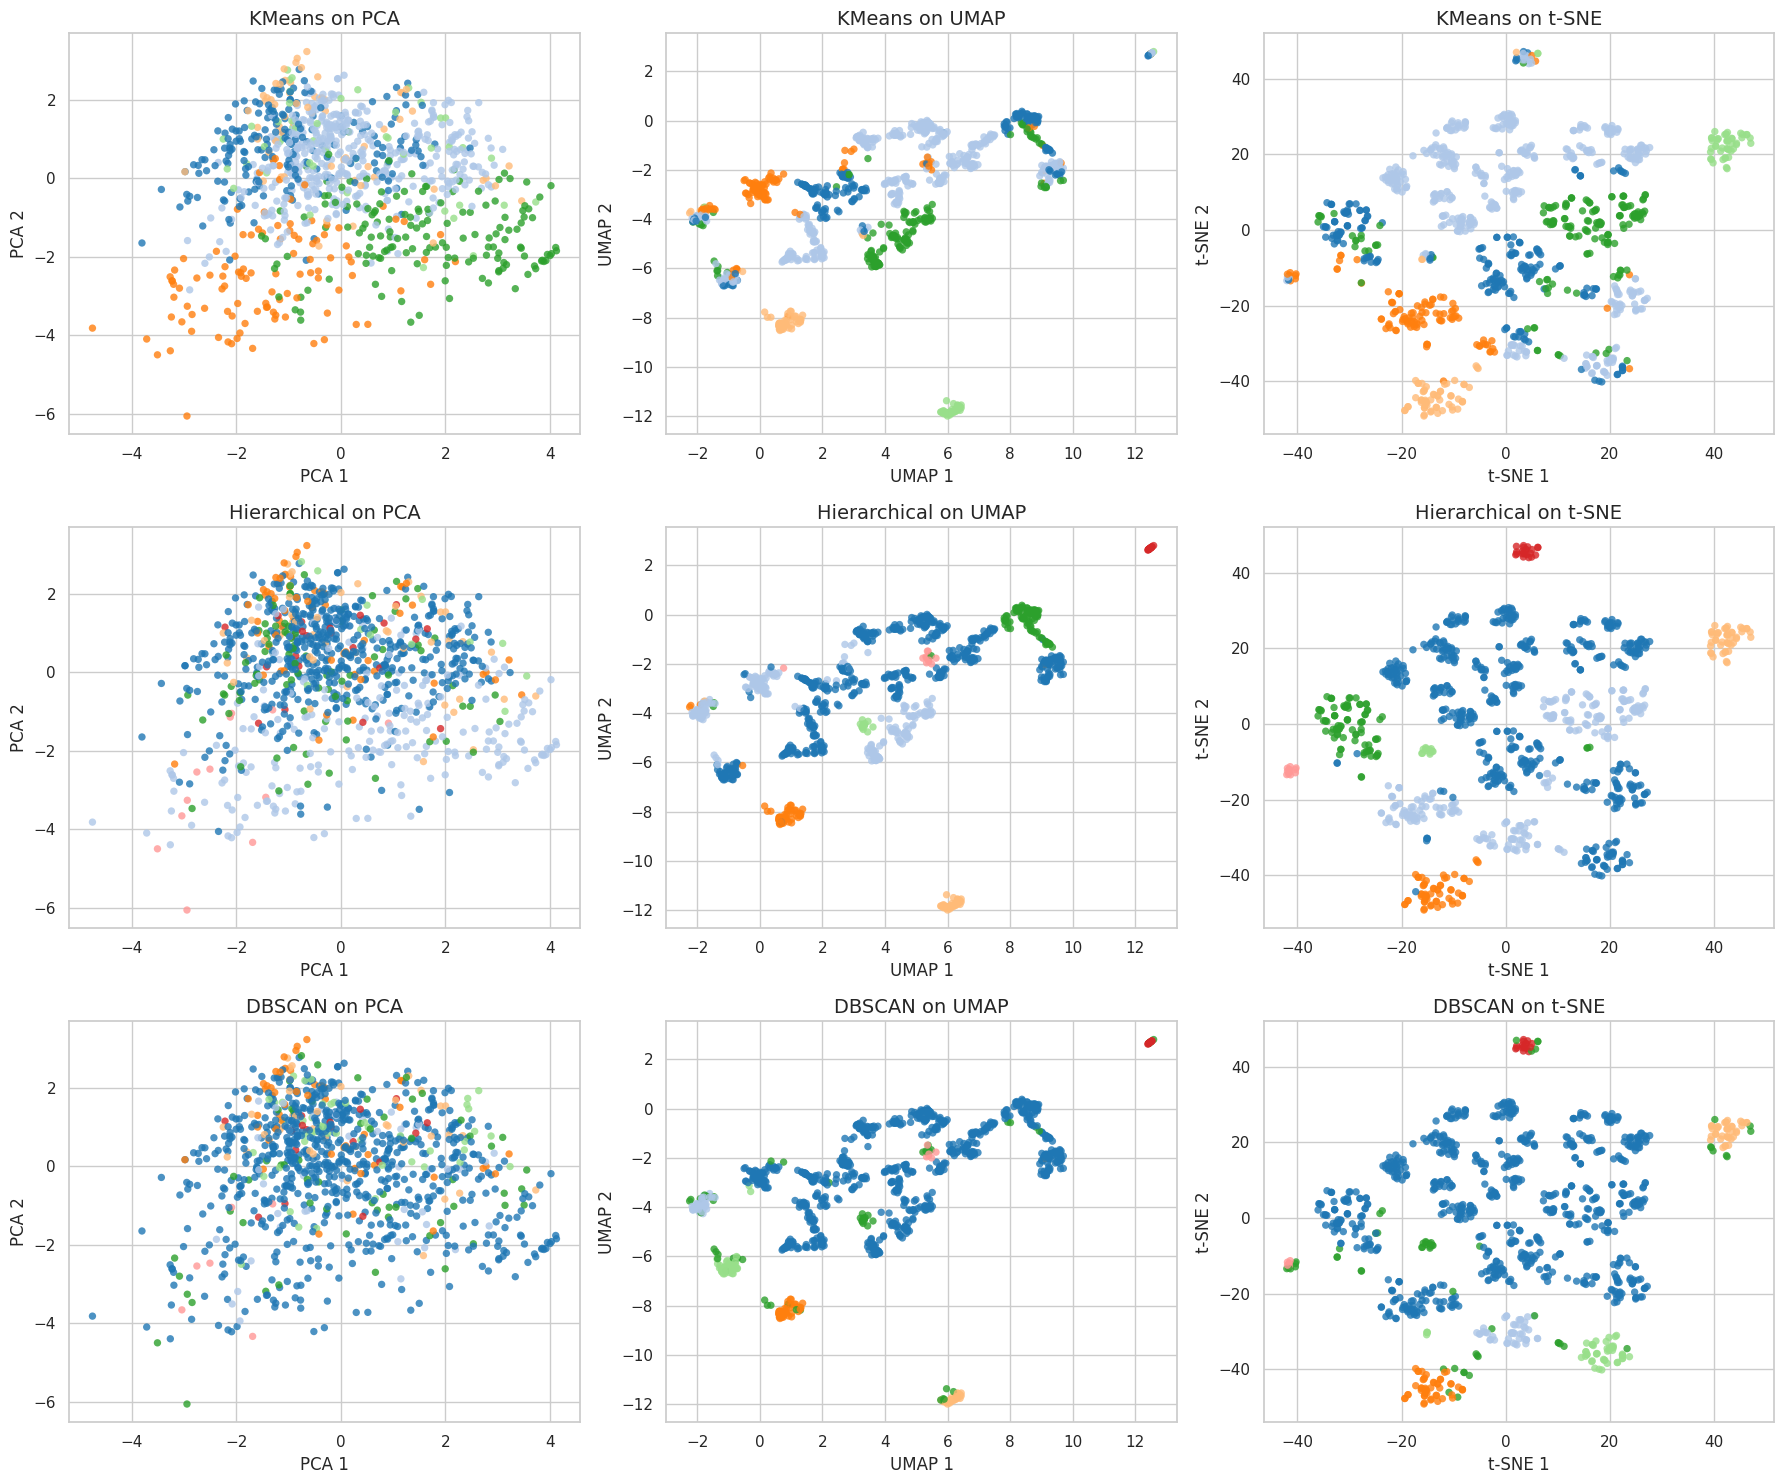

In [34]:
model_labels = {
    'KMeans': kmeans_labels,
    'Hierarchical': agg_labels,
    'DBSCAN': dbscan_labels
}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row_idx, (model_name, labels) in enumerate(model_labels.items()):
    for col_idx, (emb_name, emb_values) in enumerate(embeddings.items()):
        ax = axes[row_idx, col_idx]

        plot_df = pd.DataFrame({
            'x': emb_values[:, 0],
            'y': emb_values[:, 1]
        })

        if model_name == 'DBSCAN':
            hue_labels = pd.Series(labels).astype(str).replace({'-1': 'noise'})
        else:
            hue_labels = pd.Series(labels).astype(str)

        sns.scatterplot(
            data=plot_df,
            x='x',
            y='y',
            hue=hue_labels,
            palette='tab20',
            s=28,
            alpha=0.8,
            linewidth=0,
            ax=ax,
            legend=False
        )

        ax.set_title(f'{model_name} on {emb_name}')
        ax.set_xlabel(f'{emb_name} 1')
        ax.set_ylabel(f'{emb_name} 2')

plt.tight_layout()
plt.show()


### Результат Часть 2
- Построены три метода кластеризации: `KMeans`, `Hierarchical`, `DBSCAN`.
- Для `KMeans` и `Hierarchical` подобрано число кластеров через комбинацию `Elbow + Silhouette`.
- Для `DBSCAN` параметры выбраны через `k-distance (Elbow)` и сеточный анализ `eps/min_samples` с учетом качества и доли шума.
- Получены визуализации кластеров на плоскости в пространствах `PCA`, `UMAP`, `t-SNE`.
- Подготовлен датафрейм `df_for_interpretation` с кластерными метками для следующего этапа интерпретации.


## Часть 3. Интерпретация

Цель: понять, **чем отличаются найденные кластеры**, и можно ли дать им осмысленные профили.

Что делаем:
1. Считаем средние значения признаков по кластерам.
2. Смотрим, какие признаки дают наибольшее межкластерное различие.
3. Строим boxplot для признаков по кластерам и формулируем интерпретацию.


In [35]:
from IPython.display import display

numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration']
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

cluster_map = {
    'KMeans': 'cluster_kmeans',
    'Hierarchical': 'cluster_hierarchical',
    'DBSCAN': 'cluster_dbscan'
}


### 3.1 Средние значения признаков по кластерам

In [36]:
for model_name, cluster_col in cluster_map.items():
    print(f'\n===== {model_name} =====')

    cluster_sizes = (
        df_for_interpretation[cluster_col]
        .value_counts()
        .sort_index()
        .rename('cluster_size')
        .to_frame()
    )

    cluster_means = (
        df_for_interpretation
        .groupby(cluster_col)[numeric_cols]
        .mean()
        .round(2)
    )

    display(cluster_sizes)
    display(cluster_means)



===== KMeans =====


,cluster_size
cluster_kmeans,
0,48
1,202
2,156
3,106
4,426
5,62


,Age,Job,Credit amount,Duration
cluster_kmeans,,,,
0,37.17,1.85,2573.40,18.31
1,36.41,1.95,3369.80,21.82
2,29.72,1.87,3117.01,19.53
3,43.57,2.23,5540.42,28.87
4,34.91,1.84,2914.51,19.62
5,36.79,1.81,2450.26,18.56



===== Hierarchical =====


,cluster_size
cluster_hierarchical,
0,228
1,87
2,534
3,12
4,59
5,22
6,46
7,12


,Age,Job,Credit amount,Duration
cluster_hierarchical,,,,
0,35.70,2.01,3566.35,20.72
1,32.37,1.89,3434.71,23.11
2,35.61,1.89,3214.07,20.94
3,39.92,2.50,8209.33,32.33
4,36.73,1.80,2475.15,19.05
5,38.55,1.50,2728.09,19.09
6,36.26,1.85,2618.61,18.52
7,34.25,1.75,1498.00,16.83



===== DBSCAN =====


,cluster_size
cluster_dbscan,
-1,59
0,736
1,46
2,50
3,38
4,48
5,17
6,6


,Age,Job,Credit amount,Duration
cluster_dbscan,,,,
-1,38.97,1.66,3500.63,22.61
0,35.04,1.93,3368.15,21.18
1,38.28,1.83,2683.67,20.59
2,35.74,1.90,2555.98,19.52
3,35.95,1.84,2649.47,18.24
4,36.52,1.83,2409.17,17.98
5,34.65,1.65,3041.59,19.24
6,33.17,2.83,11081.67,29.33


In [37]:
def dominant_category_table(df, cluster_col, cat_cols):
    rows = []
    for cluster_id, sub_df in df.groupby(cluster_col):
        row = {'cluster': cluster_id, 'n': len(sub_df)}
        for col in cat_cols:
            top_category = sub_df[col].value_counts(normalize=True).idxmax()
            top_share = sub_df[col].value_counts(normalize=True).max()
            row[f'{col}_top'] = top_category
            row[f'{col}_top_share'] = round(float(top_share), 3)
        rows.append(row)
    return pd.DataFrame(rows).sort_values('cluster')


for model_name, cluster_col in cluster_map.items():
    print(f'\n===== {model_name}: доминирующие категории в кластерах =====')
    table = dominant_category_table(df_for_interpretation, cluster_col, categorical_cols)
    display(table)



===== KMeans: доминирующие категории в кластерах =====


,cluster,n,Sex_top,Sex_top_share,Housing_top,Housing_top_share,Saving accounts_top,Saving accounts_top_share,Checking account_top,Checking account_top_share,Purpose_top,Purpose_top_share
0,0,48,male,0.604,own,0.771,rich,1.000,no_info,0.521,car,0.375
1,1,202,male,0.757,own,0.995,no_info,0.649,no_info,0.500,car,0.376
2,2,156,female,0.519,rent,1.000,little,0.673,little,0.391,car,0.346
3,3,106,male,0.821,free,0.953,little,0.679,little,0.368,car,0.491
4,4,426,male,0.704,own,1.000,little,1.000,no_info,0.362,radio/TV,0.324
5,5,62,male,0.742,own,0.726,quite rich,1.000,no_info,0.629,radio/TV,0.371



===== Hierarchical: доминирующие категории в кластерах =====


,cluster,n,Sex_top,Sex_top_share,Housing_top,Housing_top_share,Saving accounts_top,Saving accounts_top_share,Checking account_top,Checking account_top_share,Purpose_top,Purpose_top_share
0,0,228,male,0.596,rent,0.518,little,0.741,little,0.434,car,0.408
1,1,87,male,0.724,own,0.701,moderate,1.000,moderate,0.483,car,0.414
2,2,534,male,0.728,own,0.949,little,0.760,no_info,0.395,radio/TV,0.350
3,3,12,male,0.750,own,0.667,little,0.667,moderate,0.583,vacation/others,1.000
4,4,59,male,0.729,own,0.712,quite rich,1.000,no_info,0.610,radio/TV,0.373
5,5,22,male,0.773,own,0.773,little,0.636,moderate,0.409,repairs,1.000
6,6,46,male,0.587,own,0.783,rich,1.000,no_info,0.522,car,0.391
7,7,12,male,0.500,own,0.833,little,0.500,little,0.417,domestic appliances,1.000



===== DBSCAN: доминирующие категории в кластерах =====


,cluster,n,Sex_top,Sex_top_share,Housing_top,Housing_top_share,Saving accounts_top,Saving accounts_top_share,Checking account_top,Checking account_top_share,Purpose_top,Purpose_top_share
0,-1,59,male,0.542,own,0.441,little,0.237,moderate,0.288,education,0.220
1,0,736,male,0.704,own,0.713,little,0.686,no_info,0.402,car,0.387
2,1,46,male,0.587,own,0.674,little,0.652,no_info,0.457,education,1.000
3,2,50,male,0.760,own,0.740,quite rich,1.000,no_info,0.660,radio/TV,0.440
4,3,38,male,0.605,own,0.868,rich,1.000,no_info,0.632,car,0.447
5,4,48,male,0.708,own,0.833,little,0.750,rich,1.000,radio/TV,0.438
6,5,17,male,0.765,own,0.882,little,0.706,moderate,0.471,repairs,1.000
7,6,6,male,0.833,own,1.000,little,1.000,moderate,0.667,vacation/others,1.000


Комментарий:
- Средние по числовым признакам показывают "уровень" кластера (моложе/старше, выше/ниже сумма кредита, длиннее/короче срок).
- Доли категорий помогают понять "тип" кластера (например, `Housing`, `Saving accounts`, `Purpose`).


### 3.2 Какие признаки различают кластеры сильнее всего

In [38]:
def top_separating_features(df_encoded, labels, top_n=12):
    labels_series = pd.Series(labels)

    # Для DBSCAN исключаем шум из анализа межкластерных различий
    if (labels_series == -1).any():
        mask = labels_series != -1
        labels_series = labels_series[mask]
        data = df_encoded.loc[mask]
    else:
        data = df_encoded

    cluster_means = data.groupby(labels_series).mean()

    feature_range = cluster_means.max(axis=0) - cluster_means.min(axis=0)
    feature_std = data.std(axis=0).replace(0, np.nan)

    score = (feature_range / feature_std).sort_values(ascending=False)

    return (
        pd.DataFrame({
            'feature': score.index,
            'separation_score': score.values
        })
        .head(top_n)
        .round(3)
    )


top_kmeans = top_separating_features(df_encoded, kmeans_labels)
top_hier = top_separating_features(df_encoded, agg_labels)
top_dbscan = top_separating_features(df_encoded, dbscan_labels)

print('Top features | KMeans')
display(top_kmeans)

print('Top features | Hierarchical')
display(top_hier)

print('Top features | DBSCAN (без noise=-1)')
display(top_dbscan)


Top features | KMeans


,feature,separation_score
0,Saving accounts_rich,4.676
1,Saving accounts_quite rich,4.114
2,Housing_free,3.068
3,Housing_rent,2.607
4,Housing_own,2.210
5,Saving accounts_little,2.043
6,Saving accounts_no_info,1.676
7,Age,1.217
8,Saving accounts_moderate,1.156
9,Credit amount,1.095


Top features | Hierarchical


,feature,separation_score
0,Purpose_domestic appliances,9.179
1,Purpose_vacation/others,9.179
2,Purpose_repairs,6.814
3,Saving accounts_rich,4.676
4,Saving accounts_quite rich,4.114
5,Saving accounts_moderate,3.288
6,Credit amount,2.378
7,Housing_own,1.788
8,Saving accounts_little,1.553
9,Job,1.530


Top features | DBSCAN (без noise=-1)


,feature,separation_score
0,Purpose_vacation/others,12.557
1,Purpose_repairs,7.504
2,Saving accounts_rich,5.077
3,Purpose_education,4.635
4,Checking account_rich,4.543
5,Saving accounts_quite rich,4.456
6,Credit amount,3.165
7,Saving accounts_little,2.066
8,Job,1.861
9,Checking account_moderate,1.505


Как читать `separation_score`:
- Чем выше значение, тем сильнее признак меняется между кластерами.
- Для one-hot признаков это обычно означает, что какая-то категория сильно концентрируется в отдельных кластерах.
- Для числовых — что средний уровень признака заметно отличается между кластерами.


### 3.3 Boxplot по признакам в разрезе кластеров

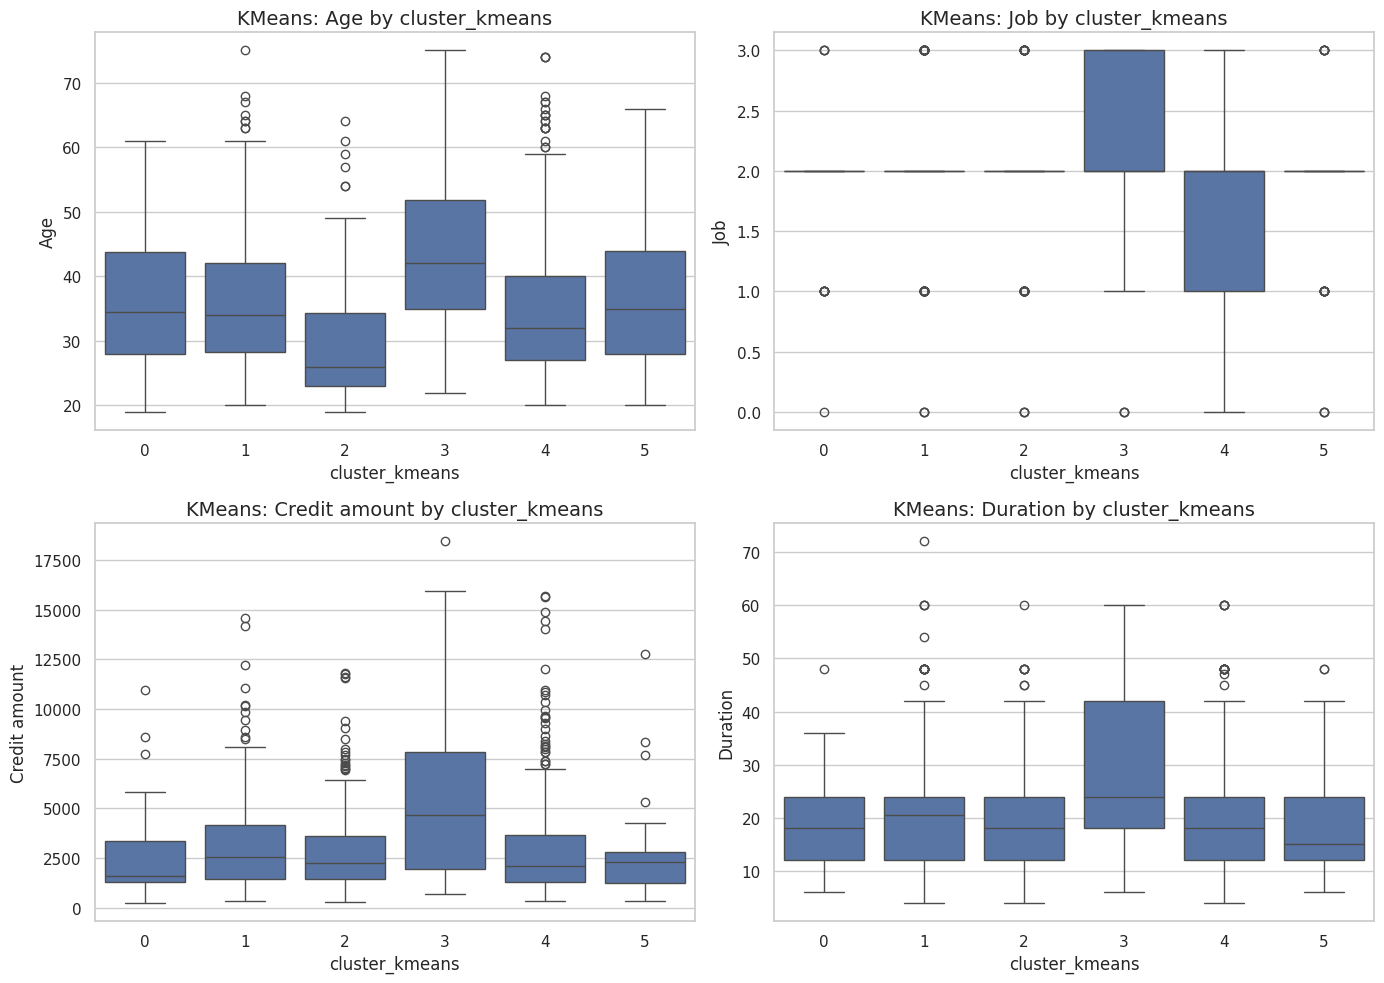

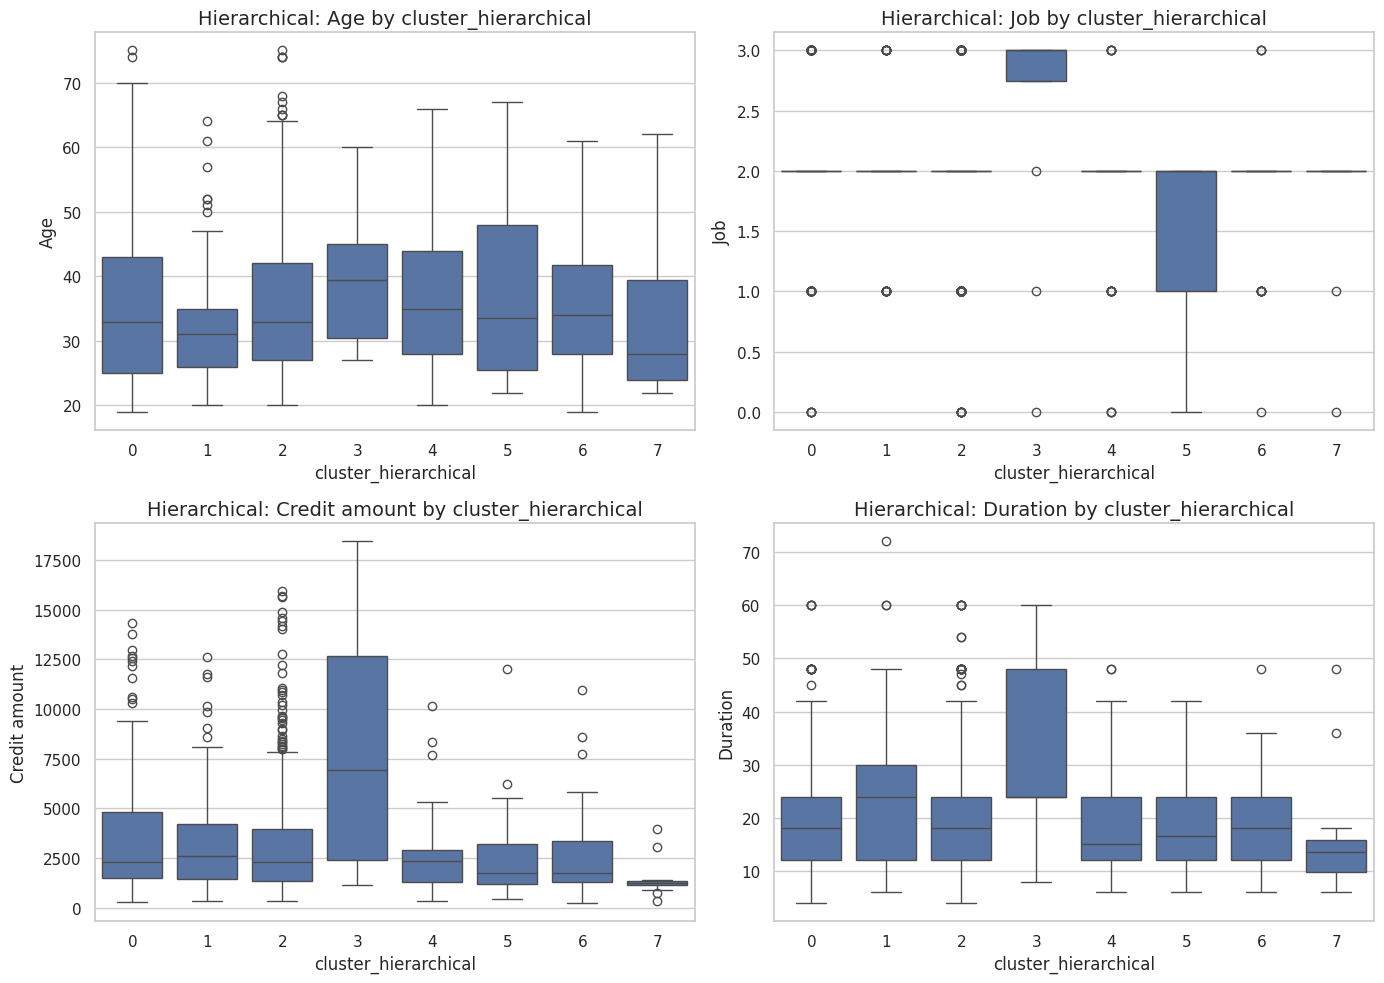

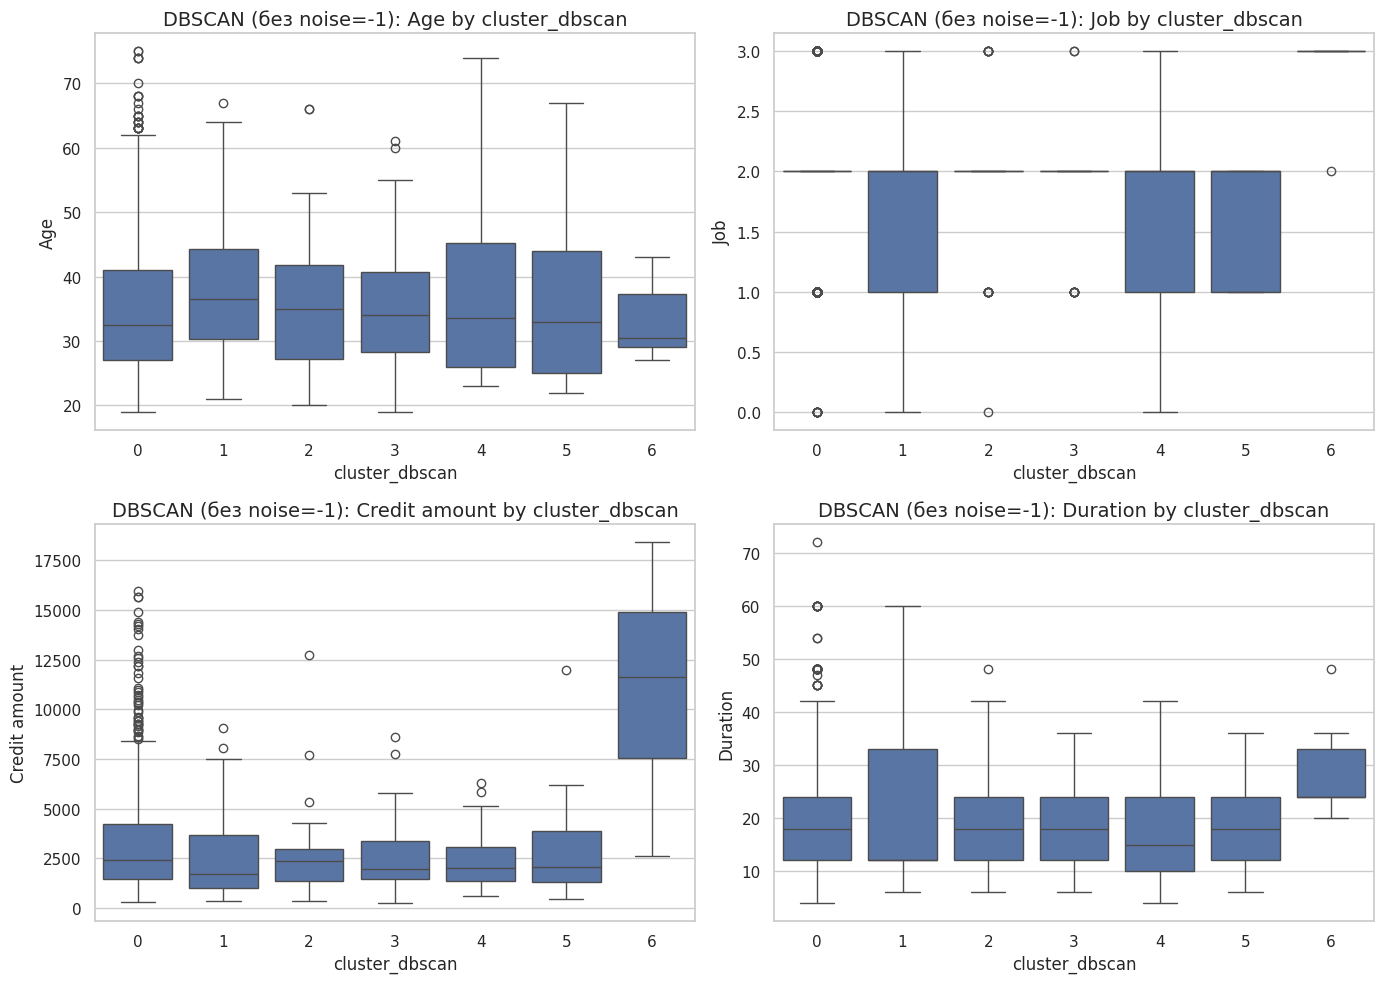

In [39]:
def plot_boxplots_by_model(df, cluster_col, model_name, numeric_cols, exclude_noise=False):
    plot_df = df.copy()

    if exclude_noise:
        plot_df = plot_df[plot_df[cluster_col] != -1]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, col in zip(axes, numeric_cols):
        sns.boxplot(data=plot_df, x=cluster_col, y=col, ax=ax)
        ax.set_title(f'{model_name}: {col} by {cluster_col}')
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()


plot_boxplots_by_model(df_for_interpretation, 'cluster_kmeans', 'KMeans', numeric_cols)
plot_boxplots_by_model(df_for_interpretation, 'cluster_hierarchical', 'Hierarchical', numeric_cols)
plot_boxplots_by_model(
    df_for_interpretation,
    'cluster_dbscan',
    'DBSCAN (без noise=-1)',
    numeric_cols,
    exclude_noise=True
)


In [40]:
def numeric_cluster_highlights(df, cluster_col, model_name):
    means = df.groupby(cluster_col)[numeric_cols].mean()

    top_credit_cluster = means['Credit amount'].idxmax()
    top_duration_cluster = means['Duration'].idxmax()
    top_age_cluster = means['Age'].idxmax()

    print(f'\n[{model_name}]')
    print(f'- Самый высокий средний Credit amount: cluster {top_credit_cluster} ({means.loc[top_credit_cluster, "Credit amount"]:.2f})')
    print(f'- Самая большая средняя Duration: cluster {top_duration_cluster} ({means.loc[top_duration_cluster, "Duration"]:.2f})')
    print(f'- Самый высокий средний Age: cluster {top_age_cluster} ({means.loc[top_age_cluster, "Age"]:.2f})')


numeric_cluster_highlights(df_for_interpretation, 'cluster_kmeans', 'KMeans')
numeric_cluster_highlights(df_for_interpretation, 'cluster_hierarchical', 'Hierarchical')
numeric_cluster_highlights(df_for_interpretation[df_for_interpretation['cluster_dbscan'] != -1], 'cluster_dbscan', 'DBSCAN (без noise)')



[KMeans]
- Самый высокий средний Credit amount: cluster 3 (5540.42)
- Самая большая средняя Duration: cluster 3 (28.87)
- Самый высокий средний Age: cluster 3 (43.57)

[Hierarchical]
- Самый высокий средний Credit amount: cluster 3 (8209.33)
- Самая большая средняя Duration: cluster 3 (32.33)
- Самый высокий средний Age: cluster 3 (39.92)

[DBSCAN (без noise)]
- Самый высокий средний Credit amount: cluster 6 (11081.67)
- Самая большая средняя Duration: cluster 6 (29.33)
- Самый высокий средний Age: cluster 1 (38.28)


### Выводы по интерпретации
1. Наиболее сильные различия между кластерами чаще всего дают финансовые категориальные признаки: `Saving accounts`, `Checking account`, а также `Housing` и `Purpose`.
2. Среди числовых признаков наиболее разделяющими оказались `Credit amount` и `Duration` (что видно и в таблицах средних, и на boxplot).
3. `KMeans` дает относительно сбалансированную и удобную для интерпретации сегментацию.
4. `Hierarchical` и `DBSCAN` дополнительно выделяют более редкие, нишевые группы (в том числе маленькие кластеры и, для DBSCAN, шум).

Практический смысл:
- Для бизнес-сегментации можно использовать `KMeans` как базовую модель профилирования.
- `DBSCAN` полезен как инструмент поиска атипичных клиентов/нишевых сегментов.
